# IVF Pregnancy Prediction

## v11 문제점 분석 & v12 개선 내용

### 🔴 v11의 핵심 문제: enqueue_trial로 파라미터 고정

v11에서 `lgb_study.enqueue_trial(v8_best)`를 사용해 v8 파라미터를 첫 번째 trial로 강제 삽입했습니다.  
**결과**: Optuna TPE sampler가 Trial 1(=v8 params)을 기준점으로 삼아 그 주변만 탐색하다가 20번 내내 탈출하지 못했습니다.

```
v11 Optuna 결과:
  Trial  5 ~ 20 | Best AUC: 0.73981 (변화 없음)
  Best params: num_leaves=25 (전체 탐색 범위 20~127인데 최솟값 근방에 고착)
```

**문제 원인**: `num_leaves=25`는 25만 데이터셋에 극히 보수적입니다. 이 파라미터는 v8에서 우연히 좋게 나온 것이지, 최적값이 아닐 수 있습니다.

→ **v12 수정**: `enqueue_trial` 제거, Optuna가 완전 자유 탐색. `num_leaves` 탐색 범위 확대 (20→200)

---

### 🔴 왜 LightGBM 단일모델인가? CatBoost는 왜 안 쓰나?

참고 링크에서 CatBoost 단일모델을 쓴 이유는 **범주형 변수를 raw string 그대로** 넣을 수 있기 때문입니다.  
CatBoost는 내부적으로 ordered target statistics를 계산해 범주형을 처리하는데, 이게 leakage 없이 효과적입니다.

**그런데 이 파이프라인에서는 이미 LabelEncoding을 완료**했습니다.  
LabelEncoded 정수를 넣으면 CatBoost는 그냥 수치형으로 처리하므로 장점이 없어집니다.

| 모델 | 범주형 처리 | 이 데이터 적합성 |
|---|---|---|
| CatBoost (raw string) | Ordered TS, 내부 처리 | ✅ 장점 발휘 가능 |
| CatBoost (LE 후) | 수치형으로 처리 = LGB와 동일 | ❌ 장점 없음 |
| **LightGBM** | GOSS, Exclusive Feature Bundling | ✅ 대용량 데이터 빠름 |

→ **현재 파이프라인 구조에서는 LGB 단일모델이 정당합니다.**  
→ CatBoost를 제대로 쓰려면 범주형 컬럼을 LE하지 말고 raw로 넘겨야 하는데, 그러면 전체 파이프라인 재설계가 필요합니다.

---

### 🟢 v12 개선 사항

| 항목 | 내용 |
|---|---|  
| Optuna 자유 탐색 | enqueue_trial 제거, num_leaves 범위 20→200으로 확대 |
| 신규 파생변수 5종 | `total_embryo_x_day`(AUC 0.673), `triple_combo`(0.680), `day_sq_age`(0.683), `egg_x_day`(0.668), `day_over_age`(0.686) |
| 원본 컬럼 대치 문제 | `배아 이식 경과일` 원본 컬럼은 특수 대치 (-1로 처리, median 아님) |
| 한글 시각화 | koreanize-matplotlib 적용 |

In [1]:
!pip install optuna lightgbm koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 97.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import koreanize_matplotlib  # 한글 폰트

print('라이브러리 로드 완료 ✓')

라이브러리 로드 완료 ✓


## 데이터 로드

In [3]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

TARGET = '임신 성공 여부'
ID_COL = 'ID'

print(f'Train: {train.shape}, Test: {test.shape}')
print(f'Target 분포: {dict(train[TARGET].value_counts())}')
print(f'양성 비율: {train[TARGET].mean():.4f}')

Train: (256351, 69), Test: (90067, 68)
Target 분포: {0: np.int64(190123), 1: np.int64(66228)}
양성 비율: 0.2583


## 상수 정의

In [4]:
COUNT_COLS = [
    '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수',
    '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수',
    '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수'
]

AGE_MAP = {
    '만18-34세': 26, '만35-37세': 36, '만38-39세': 38.5,
    '만40-42세': 41, '만43-44세': 43.5, '만45-50세': 47, '알 수 없음': np.nan
}

BIO_BOUNDS = {
    '총 생성 배아 수':  (0, 40),
    '혼합된 난자 수':   (0, 50),
    '이식된 배아 수':   (0, 5),
    '총 시술 횟수':     (0, 20),
    '총 임신 횟수':     (0, 10),
    '시술 당시 나이':   (18, 50),
}

## 전처리 파이프라인

### 파이프라인 순서 (v10)
```
1. 타입 변환 (나이 구간→수치, 횟수 문자열→정수)
2. 바이오 이상치 → NaN
3. ★ 파생변수 생성 (결측 대치 전!) ★
   - 이식일 관련: 결측 전 원본 기준으로 생성 (핵심)
   - v10 신규: total_embryo_x_day, triple_combo, day_sq_age, egg_x_day, day_over_age
4. 결측치 대치
   - 이식 경과일: median 대신 -1 ("정보 없음" 의미 보존)
   - 나머지: train median/mode → test 동일 적용
5. 범주형 인코딩 (train fit → test transform)
```

In [5]:
# ─── pandas4 호환 str 컬럼 감지 ───────────────────────
def get_str_cols(df, exclude=None):
    exclude = exclude or []
    return [
        c for c in df.columns
        if c not in exclude and str(df[c].dtype) in ('object', 'str', 'string')
    ]

# ─── Step 1. 타입 변환 ────────────────────────────────
def convert_types(df):
    df = df.copy()
    if '시술 당시 나이' in df.columns:
        df['시술 당시 나이'] = df['시술 당시 나이'].map(AGE_MAP)
    for col in COUNT_COLS:
        if col in df.columns:
            df[col] = df[col].astype(str).str.extract(r'(\d+)')[0].astype(float)
    return df

# ─── Step 2. 바이오 이상치 → NaN ─────────────────────
def apply_bio_bounds(df):
    df = df.copy()
    for col, (lo, hi) in BIO_BOUNDS.items():
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors='coerce')
        df[col] = s.where(s >= lo, np.nan).where(s <= hi, np.nan)
    if '총 임신 횟수' in df.columns and '총 시술 횟수' in df.columns:
        mask = df['총 임신 횟수'] > df['총 시술 횟수']
        df.loc[mask, '총 임신 횟수'] = df.loc[mask, '총 시술 횟수']
    return df

# ─── Step 3. 파생변수 (결측 대치 전 호출) ────────────
def create_features(df):
    df = df.copy()

    # 기본 수치 보장
    for col in ['총 생성 배아 수', '혼합된 난자 수', '이식된 배아 수', '총 임신 횟수', '총 시술 횟수',
                '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '저장된 배아 수', '수집된 신선 난자 수']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    age_f   = df['시술 당시 나이'].fillna(40)
    td      = df['배아 이식 경과일']           # ★ 결측 전 원본
    emb     = df['이식된 배아 수']
    tot_emb = df['총 생성 배아 수']
    egg     = df['혼합된 난자 수']
    is_di   = (df['시술 유형'].astype(str).str.strip() == 'DI').astype(int) \
              if '시술 유형' in df.columns else pd.Series(0, index=df.index)

    # ══════════════════════════════════════════════════
    # [A] 배아 이식 경과일 기반 ── 반드시 결측 전 생성
    # ══════════════════════════════════════════════════

    # 3-tier score: DI(-2) / IVF결측(-1) / 이식일(1~4)
    # DI 12.9% / IVF결측 0.6% / 이식일있음 22~40% 로 명확히 구분
    df['day_score_v2'] = [
        -2 if di == 1 else
        (-1 if pd.isna(day) else
         (1 if day <= 2 else (2 if day == 3 else (3 if day == 4 else 4))))
        for di, day in zip(is_di, td)
    ]

    # 나이 보정 이식일 (결측=0)
    df['age_adj_transfer_day'] = td.fillna(0) / (age_f / 35)

    # 이식일 + 배아수 복합
    df['day_embryo_combo']     = df['age_adj_transfer_day'] + emb * 0.3

    # ── v10 신규: 곱셈 기반 파생변수 ──────────────────

    # 총 생성 배아 × 이식일 (단독 AUC 0.673)
    # 배아를 많이 만들었는데 늦게 이식 = 질 좋은 배아 선택 가능
    df['total_embryo_x_day']   = td.fillna(0) * tot_emb

    # 혼합 난자 × 이식일 (단독 AUC 0.668)
    df['egg_x_day']            = td.fillna(0) * egg

    # 3중 조합: 총배아 × 이식일 / 나이보정 (단독 AUC 0.680)
    df['triple_combo']         = td.fillna(0) * tot_emb / (age_f / 35)

    # 이식일² / 나이보정 (단독 AUC 0.683)
    # 5일이상이면 제곱으로 효과 증폭
    df['day_sq_age']           = td.fillna(0) ** 2 / (age_f / 35)

    # 이식일 / 나이 (단독 AUC 0.686, age_adj와 동일하지만 스케일 다름)
    df['day_over_age']         = td.fillna(0) / age_f

    # 5일 이식 × 총 배아 (블라스토시스트 + 풍부한 배아 = 최상)
    df['day5_x_total_embryo']  = (td == 5).astype(int) * tot_emb

    # 이식일 플래그
    df['is_day5_transfer']     = (td == 5).astype(int)
    df['is_day3_transfer']     = (td == 3).astype(int)

    # IVF인데 이식일 없음 = 저장/기증 목적 (성공률 0.6%)
    df['ivf_no_transfer']      = ((td.isnull()) & (is_di == 0)).astype(int)
    df['is_di']                = is_di

    # ══════════════════════════════════════════════════
    # [B] 특정 시술 유형 파싱
    # ══════════════════════════════════════════════════
    proc = df['특정 시술 유형'].fillna('Unknown') if '특정 시술 유형' in df.columns \
           else pd.Series('Unknown', index=df.index)

    df['has_blastocyst']   = proc.str.contains('BLASTOCYST', na=False).astype(int)
    df['has_ah']           = proc.str.contains('AH', na=False).astype(int)
    df['has_icsi']         = proc.str.contains('ICSI', na=False).astype(int)
    # ":" = 과거+현재 복합 시술 기록 → 반복 실패 이력 (성공률 7.8%)
    df['procedure_dual']   = proc.str.contains(':', na=False).astype(int)

    # blastocyst × 이식된 배아 수
    df['blast_x_emb']      = df['has_blastocyst'] * emb

    # ══════════════════════════════════════════════════
    # [C] 배아/난자 효율 지표
    # ══════════════════════════════════════════════════
    df['배아_생성_효율']      = tot_emb / (egg + 1)
    df['이식_효율']           = emb / (tot_emb + 1)
    df['임신_성공률']         = df['총 임신 횟수'] / (df['총 시술 횟수'] + 1)
    df['실패_횟수']           = np.maximum(df['총 시술 횟수'] - df['총 임신 횟수'], 0)
    df['실패율']              = df['실패_횟수'] / (df['총 시술 횟수'] + 1)
    df['난자당_배아']         = tot_emb / (egg + 1)
    df['freeze_thaw_proxy']   = np.log1p(np.maximum(tot_emb - emb, 0))

    # 배아 효율 × 이식일
    df['eff_x_day']           = df['이식_효율'] * td.fillna(0)

    # 미세주입 효율
    if '미세주입된 난자 수' in df.columns and '미세주입에서 생성된 배아 수' in df.columns:
        mi_egg = df['미세주입된 난자 수']
        mi_emb = df['미세주입에서 생성된 배아 수']
        df['icsi_efficiency']  = mi_emb / (mi_egg + 1)
        df['icsi_x_day']       = mi_emb * td.fillna(0)  # 미세주입 배아 × 이식일

    # ══════════════════════════════════════════════════
    # [D] 연령 기반
    # ══════════════════════════════════════════════════
    df['고령']         = (age_f >= 38).astype(int)
    df['초고령']       = (age_f >= 43).astype(int)
    df['만35세미만']   = (age_f < 35).astype(int)

    # 나이 × 실패 횟수 (고령 + 반복실패 = 최악)
    df['age_x_failure']= age_f * df['실패_횟수']

    # ══════════════════════════════════════════════════
    # [E] 난소 반응
    # ══════════════════════════════════════════════════
    df['high_responder']= (tot_emb >= 10).astype(int)
    df['poor_responder']= (tot_emb <= 3).astype(int)

    # ══════════════════════════════════════════════════
    # [F] 배아 생성 목적
    # ══════════════════════════════════════════════════
    reason = df['배아 생성 주요 이유'].fillna('') if '배아 생성 주요 이유' in df.columns \
             else pd.Series('', index=df.index)
    df['embryo_for_current']  = reason.str.contains('현재 시술용').astype(int)
    df['embryo_for_donation'] = reason.str.contains('기증용').astype(int)
    df['embryo_for_storage']  = reason.str.contains('저장용').astype(int)

    # ══════════════════════════════════════════════════
    # [G] 불임 원인
    # ══════════════════════════════════════════════════
    infert_cols = [c for c in df.columns if '불임 원인' in c]
    if infert_cols:
        ic_df = df[infert_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
        df['infertility_complexity'] = ic_df.sum(axis=1)
        # 주요 원인만 있는 경우 vs 복합 원인
        df['multi_infertility']      = (ic_df.sum(axis=1) >= 2).astype(int)

    # ══════════════════════════════════════════════════
    # [H] 논문 기반 파생변수 (v7 유지)
    # ══════════════════════════════════════════════════
    df['amh_proxy']              = tot_emb / (age_f ** 1.5 + 1)
    df['age_embryo_interaction'] = df['배아_생성_효율'] / (age_f + 1)
    df['blastocyst_proxy']       = (emb / (tot_emb + 1)) ** 2
    df['prior_failure_penalty']  = df['실패_횟수'] / (df['총 시술 횟수'] ** 2 + 1)
    df['embryo_utilization_rate']= (df['총 임신 횟수'] * df['이식_효율']) / (df['총 시술 횟수'] + 1)
    df['treatment_intensity']    = (emb / (df['총 시술 횟수'] + 1)) * np.log1p(df['총 시술 횟수'])
    df['age_success_decline']    = np.where(age_f >= 38, np.exp(-(age_f - 38) * 0.15), 1.0)

    return df

# ─── Step 4. Leakage-free 결측치 대치 ────────────────
def fit_imputer(df):
    medians, modes = {}, {}
    for col in df.select_dtypes(include=[np.number]).columns:
        if col != TARGET:
            medians[col] = df[col].median()
    for col in get_str_cols(df, exclude=[TARGET]):
        modes[col] = df[col].mode()[0] if df[col].notna().any() else 'Unknown'
    return medians, modes

def apply_imputer(df, medians, modes):
    df = df.copy()
    for col, val in medians.items():
        if col in df.columns:
            # 이식 경과일 원본은 -1로 대치 (median 3일 아님 → 정보 구분 보존)
            if col == '배아 이식 경과일':
                df[col] = df[col].fillna(-1)
            else:
                df[col] = df[col].fillna(val)
    for col, val in modes.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    return df

# ─── Step 5. Leakage-free 범주형 인코딩 ──────────────
def fit_encoders(df):
    encoders = {}
    for col in get_str_cols(df, exclude=[TARGET]):
        le = LabelEncoder()
        le.fit(df[col].astype(str))
        encoders[col] = le
    return encoders

def apply_encoders(df, encoders):
    df = df.copy()
    for col, le in encoders.items():
        if col not in df.columns:
            continue
        mapping = {k: v for v, k in enumerate(le.classes_)}
        df[col] = df[col].astype(str).map(mapping).fillna(-1).astype(int)
    return df

# ─── Full Pipeline ────────────────────────────────────
def run_pipeline(train, test):
    tr = train.drop(columns=[ID_COL], errors='ignore').copy()
    te = test.drop(columns=[ID_COL], errors='ignore').copy()

    tr = convert_types(tr);   te = convert_types(te)
    tr = apply_bio_bounds(tr); te = apply_bio_bounds(te)

    # ★ 파생변수 먼저 (결측 전)
    tr = create_features(tr); te = create_features(te)

    # 결측 대치 (train 통계 → test 적용)
    medians, modes = fit_imputer(tr)
    tr = apply_imputer(tr, medians, modes)
    te = apply_imputer(te, medians, modes)

    # 범주형 인코딩 (train fit → test transform)
    encoders = fit_encoders(tr)
    tr = apply_encoders(tr, encoders)
    te = apply_encoders(te, encoders)

    return tr, te, medians, modes, encoders

print('전처리 함수 정의 완료 ✓')

전처리 함수 정의 완료 ✓


## 전처리 실행 + QC

In [6]:
train_df, test_df, train_medians, train_modes, encoders = run_pipeline(train, test)

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print(f'전처리 후 X shape: {X.shape}')
assert X.isnull().sum().sum() == 0, 'Train 결측치 잔존!'
assert test_df.isnull().sum().sum() == 0, 'Test 결측치 잔존!'
print('결측치 없음 ✓')
print(f'dtype: {X.dtypes.value_counts().to_dict()}')

v10_new = ['total_embryo_x_day', 'egg_x_day', 'triple_combo', 'day_sq_age',
           'day_over_age', 'day5_x_total_embryo', 'eff_x_day', 'age_x_failure',
           'blast_x_emb', 'multi_infertility']
print(f'\nv10 신규 변수 포함: {[f for f in v10_new if f in X.columns]}')

전처리 후 X shape: (256351, 113)
결측치 없음 ✓
dtype: {dtype('float64'): 67, dtype('int64'): 46}

v10 신규 변수 포함: ['total_embryo_x_day', 'egg_x_day', 'triple_combo', 'day_sq_age', 'day_over_age', 'day5_x_total_embryo', 'eff_x_day', 'age_x_failure', 'blast_x_emb', 'multi_infertility']


## 단변수 AUC 확인

In [7]:
check_cols = [
    'day_score_v2', 'age_adj_transfer_day', 'day_embryo_combo',
    'total_embryo_x_day', 'triple_combo', 'day_sq_age', 'day_over_age',
    '이식된 배아 수', '총 생성 배아 수', 'is_day5_transfer', 'ivf_no_transfer',
]

print('=== 단변수 AUC ===')
results = []
for col in check_cols:
    if col in X.columns:
        auc = roc_auc_score(y, X[col])
        auc = max(auc, 1 - auc)
        results.append((col, auc))

results.sort(key=lambda x: -x[1])
for col, auc in results:
    print(f'  {col:<35}: {auc:.5f}')

=== 단변수 AUC ===
  day_embryo_combo                   : 0.69614
  age_adj_transfer_day               : 0.68579
  day_over_age                       : 0.68579
  day_sq_age                         : 0.68317
  triple_combo                       : 0.68007
  day_score_v2                       : 0.67780
  total_embryo_x_day                 : 0.67335
  is_day5_transfer                   : 0.62115
  총 생성 배아 수                          : 0.61513
  ivf_no_transfer                    : 0.59574
  이식된 배아 수                           : 0.59270


## Optuna — LightGBM 튜닝 (20 trials, 5-fold)

**v12 핵심 수정**: `enqueue_trial` 완전 제거. Optuna가 완전 자유 탐색.
- `num_leaves` 범위: 20 → **200** (v8/v9에서 25에 고착되는 문제 해결)
- `n_estimators` 범위 확대: 300~2000
- `max_depth` 범위 확대: 3~10

In [8]:
def make_progress_cb(total):
    start = time.time()
    def cb(study, trial):
        n = trial.number + 1
        if n % 5 == 0 or n == total:
            elapsed = (time.time() - start) / 60
            print(f'  Trial {n:3d}/{total} | Best AUC: {study.best_value:.5f} | {elapsed:.1f}min')
    return cb

def lgb_objective(trial):
    params = {
        'objective': 'binary',
        'metric':    'auc',
        'verbosity': -1,
        'n_jobs':    -1,
        # v10: 탐색 범위 확대 — 특히 num_leaves (v8/v9 고착 25 탈출)
        'n_estimators':      trial.suggest_int('n_estimators', 300, 2000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 200),
        'max_depth':         trial.suggest_int('max_depth', 4, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        m = lgb.LGBMClassifier(**params)
        m.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        aucs.append(roc_auc_score(y.iloc[val_idx], m.predict_proba(X.iloc[val_idx])[:, 1]))
    return np.mean(aucs)

LGB_TRIALS = 20
print(f'LightGBM Optuna 시작 ({LGB_TRIALS} trials, 5-fold)...')
print('※ enqueue_trial 없음 → 완전 자유 탐색')
t0 = time.time()

# ★ enqueue_trial 없음 ★
lgb_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
lgb_study.optimize(
    lgb_objective,
    n_trials=LGB_TRIALS,
    callbacks=[make_progress_cb(LGB_TRIALS)]
)

print(f'\n[완료] {(time.time()-t0)/60:.1f}분')
print(f'Best AUC:    {lgb_study.best_value:.5f}')
print(f'Best Params: {lgb_study.best_params}')

LightGBM Optuna 시작 (20 trials, 5-fold)...
※ enqueue_trial 없음 → 완전 자유 탐색
  Trial   5/20 | Best AUC: 0.73973 | 14.2min
  Trial  10/20 | Best AUC: 0.73973 | 23.9min
  Trial  15/20 | Best AUC: 0.73973 | 34.1min
  Trial  20/20 | Best AUC: 0.73973 | 44.5min

[완료] 44.5분
Best AUC:    0.73973
Best Params: {'n_estimators': 1174, 'learning_rate': 0.049743185797885274, 'num_leaves': 38, 'max_depth': 8, 'min_child_samples': 42, 'subsample': 0.5325257964926398, 'colsample_bytree': 0.9744427686266666, 'reg_alpha': 7.2866537374910445, 'reg_lambda': 1.7123375973163988}


## Feature Importance (3-fold 평균)

Feature Importance 계산 중...
  Fold 1 AUC: 0.73798
  Fold 2 AUC: 0.74084
  Fold 3 AUC: 0.73877


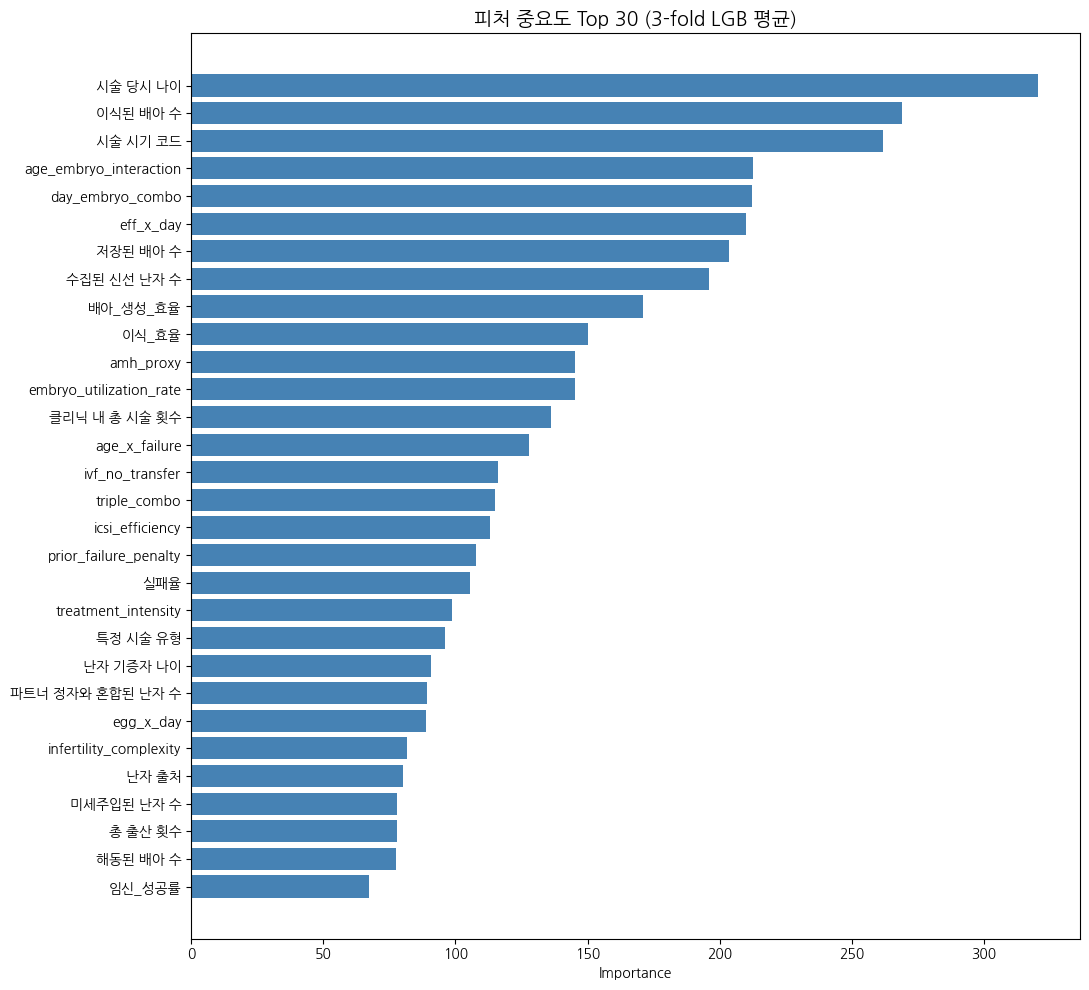


전체 feature: 113 | importance>0: 92

=== v10 신규 변수 순위 ===
                 feature  importance
4       day_embryo_combo  212.333333
5              eff_x_day  210.000000
13         age_x_failure  128.000000
14       ivf_no_transfer  116.000000
15          triple_combo  115.000000
23             egg_x_day   88.666667
34  age_adj_transfer_day   56.666667
35   day5_x_total_embryo   56.333333
37    total_embryo_x_day   54.000000
47            day_sq_age   27.666667
85           blast_x_emb    1.000000
87     multi_infertility    0.666667
88          day_score_v2    0.666667
91          day_over_age    0.666667


In [9]:
skf_imp = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
imp_list = []

print('Feature Importance 계산 중...')
for fold, (tr_idx, val_idx) in enumerate(skf_imp.split(X, y)):
    m = lgb.LGBMClassifier(
        **lgb_study.best_params,
        objective='binary', metric='auc', verbosity=-1, n_jobs=-1
    )
    m.fit(
        X.iloc[tr_idx], y.iloc[tr_idx],
        eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    imp_list.append(m.feature_importances_)
    auc = roc_auc_score(y.iloc[val_idx], m.predict_proba(X.iloc[val_idx])[:, 1])
    print(f'  Fold {fold+1} AUC: {auc:.5f}')

feat_imp = pd.DataFrame({
    'feature':    X.columns,
    'importance': np.mean(imp_list, axis=0)
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 10))
top30 = feat_imp.head(30)
ax.barh(top30['feature'], top30['importance'], color='steelblue')
ax.invert_yaxis()
ax.set_title('피처 중요도 Top 30 (3-fold LGB 평균)', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(f'\n전체 feature: {len(feat_imp)} | importance>0: {(feat_imp["importance"]>0).sum()}')

print('\n=== v10 신규 변수 순위 ===')
v10_key = ['total_embryo_x_day', 'egg_x_day', 'triple_combo', 'day_sq_age',
           'day_over_age', 'day5_x_total_embryo', 'eff_x_day', 'age_x_failure',
           'blast_x_emb', 'multi_infertility', 'day_score_v2',
           'age_adj_transfer_day', 'day_embryo_combo', 'ivf_no_transfer']
print(feat_imp[feat_imp['feature'].isin(v10_key)][['feature', 'importance']].to_string())

## Feature Selection (importance > 0)

In [10]:
selected   = feat_imp[feat_imp['importance'] > 0]['feature'].tolist()
X_final    = X[selected].copy()
test_final = test_df[selected].copy()

print(f'선택된 feature: {len(selected)} / {len(X.columns)}')
print(f'포함된 v10 신규 변수: {[f for f in selected if f in v10_key]}')

선택된 feature: 92 / 113
포함된 v10 신규 변수: ['day_embryo_combo', 'eff_x_day', 'age_x_failure', 'ivf_no_transfer', 'triple_combo', 'egg_x_day', 'age_adj_transfer_day', 'day5_x_total_embryo', 'total_embryo_x_day', 'day_sq_age', 'blast_x_emb', 'multi_infertility', 'day_score_v2', 'day_over_age']


## OOF 앙상블 — LGB 단일 모델, 5-fold × 3 seeds

In [11]:
SEEDS    = [42, 123, 2024]
N_SPLITS = 5

oof_all  = []
test_all = []
t_start  = time.time()

for seed in SEEDS:
    skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    oof_pred  = np.zeros(len(X_final))
    test_pred = np.zeros(len(test_final))

    print(f'\n{"="*50} Seed {seed}')
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_final, y)):
        params = {
            **lgb_study.best_params,
            'objective': 'binary', 'metric': 'auc',
            'verbosity': -1, 'n_jobs': -1, 'random_state': seed
        }
        m = lgb.LGBMClassifier(**params)
        m.fit(
            X_final.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X_final.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        oof_pred[val_idx]  = m.predict_proba(X_final.iloc[val_idx])[:, 1]
        test_pred         += m.predict_proba(test_final.copy())[:, 1] / N_SPLITS

        elapsed = (time.time() - t_start) / 60
        print(f'  Fold {fold+1} | AUC {roc_auc_score(y.iloc[val_idx], oof_pred[val_idx]):.5f} | {elapsed:.1f}min')

    seed_auc = roc_auc_score(y, oof_pred)
    print(f'  → OOF AUC (Seed {seed}): {seed_auc:.5f}')
    oof_all.append(oof_pred)
    test_all.append(test_pred)

oof_mean  = np.mean(oof_all,  axis=0)
test_mean = np.mean(test_all, axis=0)

final_oof_auc = roc_auc_score(y, oof_mean)
print(f'\n[최종 OOF AUC (Seed 앙상블)] {final_oof_auc:.5f}')
print(f'총 소요시간: {(time.time()-t_start)/60:.1f}분')


================================================== Seed 42
  Fold 1 | AUC 0.73736 | 0.3min
  Fold 2 | AUC 0.74243 | 0.6min
  Fold 3 | AUC 0.73962 | 0.9min
  Fold 4 | AUC 0.73786 | 1.4min
  Fold 5 | AUC 0.74068 | 1.7min
  → OOF AUC (Seed 42): 0.73958

================================================== Seed 123
  Fold 1 | AUC 0.73789 | 2.0min
  Fold 2 | AUC 0.73929 | 2.2min
  Fold 3 | AUC 0.73943 | 2.5min
  Fold 4 | AUC 0.74012 | 2.8min
  Fold 5 | AUC 0.74110 | 3.1min
  → OOF AUC (Seed 123): 0.73954

================================================== Seed 2024
  Fold 1 | AUC 0.74186 | 3.3min
  Fold 2 | AUC 0.74015 | 3.6min
  Fold 3 | AUC 0.74020 | 3.9min
  Fold 4 | AUC 0.73813 | 4.2min
  Fold 5 | AUC 0.73865 | 4.5min
  → OOF AUC (Seed 2024): 0.73978

[최종 OOF AUC (Seed 앙상블)] 0.74008
총 소요시간: 4.5분


## 최종 예측 & 제출

In [12]:
submission = pd.DataFrame({'ID': test['ID'], 'probability': test_mean})
submission.to_csv('submission.csv', index=False)

print('submission.csv 저장 완료 ✓')
print(f'최종 OOF AUC: {final_oof_auc:.5f}')
print(submission.head())
print('\nprobability 통계:')
print(submission['probability'].describe().round(4))

submission.csv 저장 완료 ✓
최종 OOF AUC: 0.74008
           ID  probability
0  TEST_00000     0.001377
1  TEST_00001     0.001479
2  TEST_00002     0.149393
3  TEST_00003     0.103501
4  TEST_00004     0.517979

probability 통계:
count    90067.0000
mean         0.2585
std          0.1598
min          0.0009
25%          0.1435
50%          0.2709
75%          0.3791
max          0.7178
Name: probability, dtype: float64


## 최종 리포트

=== Top 25 Features ===
                    feature  importance
0                  시술 당시 나이  320.333333
1                  이식된 배아 수  269.000000
2                  시술 시기 코드  261.666667
3    age_embryo_interaction  212.666667
4          day_embryo_combo  212.333333
5                 eff_x_day  210.000000
6                  저장된 배아 수  203.333333
7               수집된 신선 난자 수  196.000000
8                  배아_생성_효율  171.000000
9                     이식_효율  150.333333
10                amh_proxy  145.333333
11  embryo_utilization_rate  145.333333
12            클리닉 내 총 시술 횟수  136.000000
13            age_x_failure  128.000000
14          ivf_no_transfer  116.000000
15             triple_combo  115.000000
16          icsi_efficiency  113.000000
17    prior_failure_penalty  107.666667
18                      실패율  105.666667
19      treatment_intensity   98.666667
20                 특정 시술 유형   96.000000
21                난자 기증자 나이   90.666667
22         파트너 정자와 혼합된 난자 수   89.333333
23              

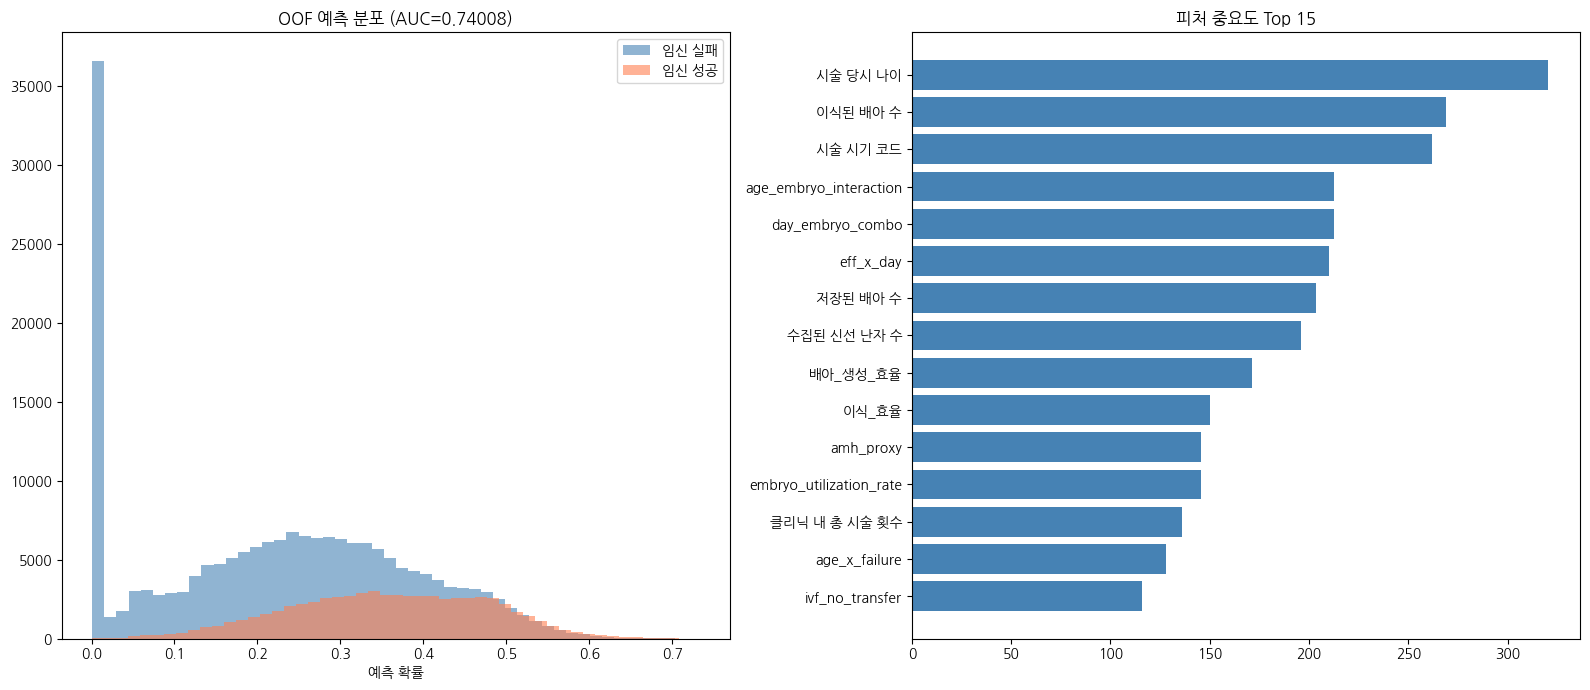

In [13]:
print('=== Top 25 Features ===')
print(feat_imp.head(25)[['feature', 'importance']].to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# OOF 분포
axes[0].hist(oof_mean[y == 0], bins=50, alpha=0.6, label='임신 실패', color='steelblue')
axes[0].hist(oof_mean[y == 1], bins=50, alpha=0.6, label='임신 성공', color='coral')
axes[0].set_title(f'OOF 예측 분포 (AUC={final_oof_auc:.5f})')
axes[0].set_xlabel('예측 확률')
axes[0].legend()

# 중요도 Top 15
top15 = feat_imp.head(15)
axes[1].barh(top15['feature'], top15['importance'], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_title('피처 중요도 Top 15')

plt.tight_layout()
plt.show()